In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.signal import convolve
from scipy.fft import fft, ifft

In [2]:
file_path = r"C:\Users\devah\Downloads\Matti-Tisava-Matti-Bommanu-Chesava.wav"

if not os.path.exists(file_path):
    raise FileNotFoundError("Audio file not found.")

fs, audio = wavfile.read(file_path)

if audio.ndim == 2:
    audio = np.mean(audio, axis=1)

audio = audio.astype(np.float32)

audio = audio / np.max(np.abs(audio))

audio_folder = "Processed_Audio"
graph_folder = "Graphs"

os.makedirs(audio_folder, exist_ok=True)
os.makedirs(graph_folder, exist_ok=True)

print("=" * 60)
print("Audio Loaded Successfully")
print("=" * 60)
print("Sampling Rate :", fs)
print("Total Samples :", len(audio))
print("Duration      :", round(len(audio) / fs, 2), "seconds")
print("Audio Folder  :", os.path.abspath(audio_folder))
print("Graph Folder  :", os.path.abspath(graph_folder))

Audio Loaded Successfully
Sampling Rate : 48000
Total Samples : 19699200
Duration      : 410.4 seconds
Audio Folder  : c:\Users\devah\Documents\ICT MU\Sem 5\DSIP\Lab\Processed_Audio
Graph Folder  : c:\Users\devah\Documents\ICT MU\Sem 5\DSIP\Lab\Graphs


In [3]:
ir_identity = np.array([1.0])
ir_noise_reduction = np.ones(5) / 5

ir_lowpass = np.array([
    0.25,
    0.50,
    0.25
])

ir_highpass = np.array([
    -1,
     2,
    -1
])

ir_edge = np.array([
     1,
     0,
    -1
])

ir_sharpen = np.array([
   -0.5,
    2.0,
   -0.5
])

ir_room = np.array([
    1.0,
    0.6,
    0.3,
    0.15
])

ir_hall = np.exp(
    -np.linspace(0, 2, 25)
)

ir_echo = np.zeros(30)
ir_echo[0] = 1
ir_echo[10] = 0.6
ir_echo[20] = 0.4

ir_decay = np.exp(
    -np.linspace(0, 3, 15)
)

impulse_responses = {
    "Identity": ir_identity,
    "NoiseReduction": ir_noise_reduction,
    "LowPass": ir_lowpass,
    "HighPass": ir_highpass,
    "EdgeDetection": ir_edge,
    "Sharpen": ir_sharpen,
    "RoomReverb": ir_room,
    "HallReverb": ir_hall,
    "Echo": ir_echo,
    "Decay": ir_decay
}

print("Total Impulse Responses :", len(impulse_responses))

for name in impulse_responses:
    print(name)

Total Impulse Responses : 10
Identity
NoiseReduction
LowPass
HighPass
EdgeDetection
Sharpen
RoomReverb
HallReverb
Echo
Decay


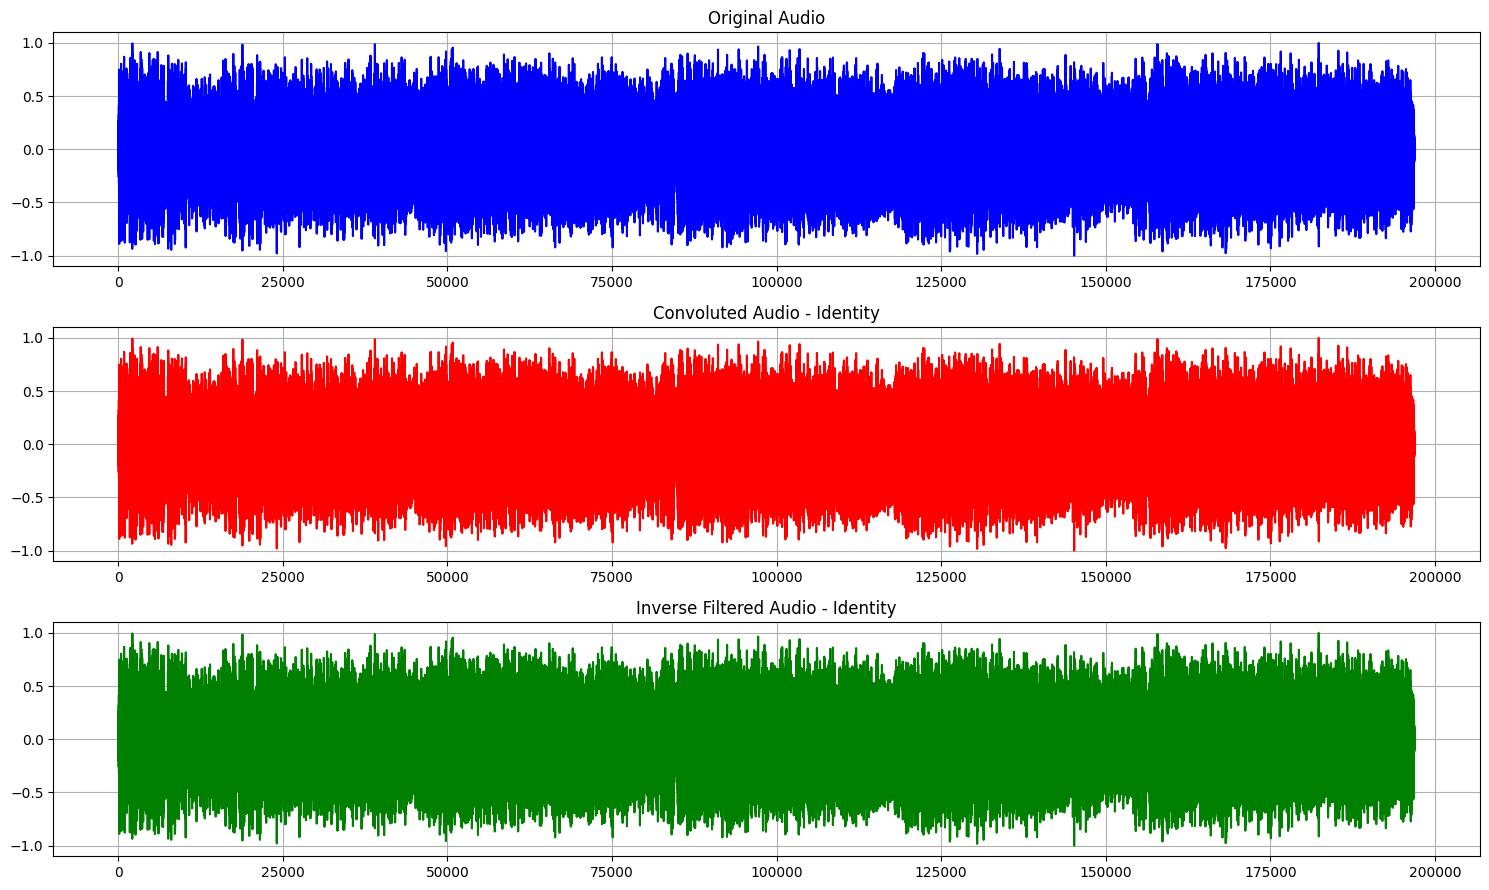

Identity Processing Completed


In [4]:
name = "Identity"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "Identity_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "Identity_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Identity")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Identity")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Identity.png"
    )
)

plt.show()

print("Identity Processing Completed")

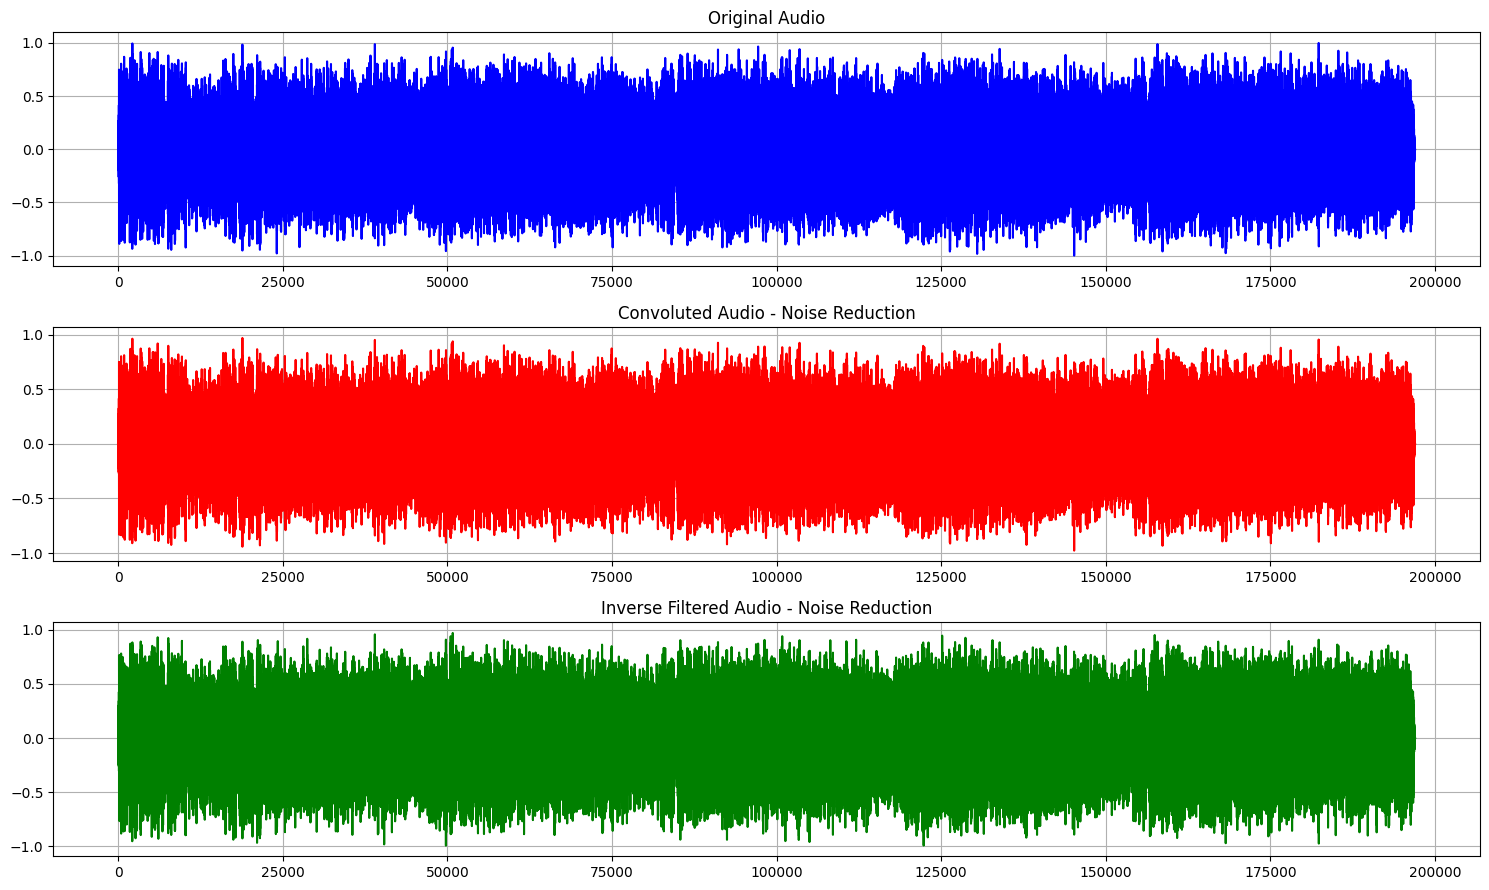

Noise Reduction Processing Completed


In [5]:
name = "NoiseReduction"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "NoiseReduction_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "NoiseReduction_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Noise Reduction")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Noise Reduction")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "NoiseReduction.png"
    )
)

plt.show()

print("Noise Reduction Processing Completed")

C:\Users\devah\AppData\Local\Temp\ipykernel_15080\1564470523.py:15: RuntimeWarning: divide by zero encountered in divide
  1 / H,
C:\Users\devah\AppData\Local\Temp\ipykernel_15080\1564470523.py:15: RuntimeWarning: invalid value encountered in divide
  1 / H,


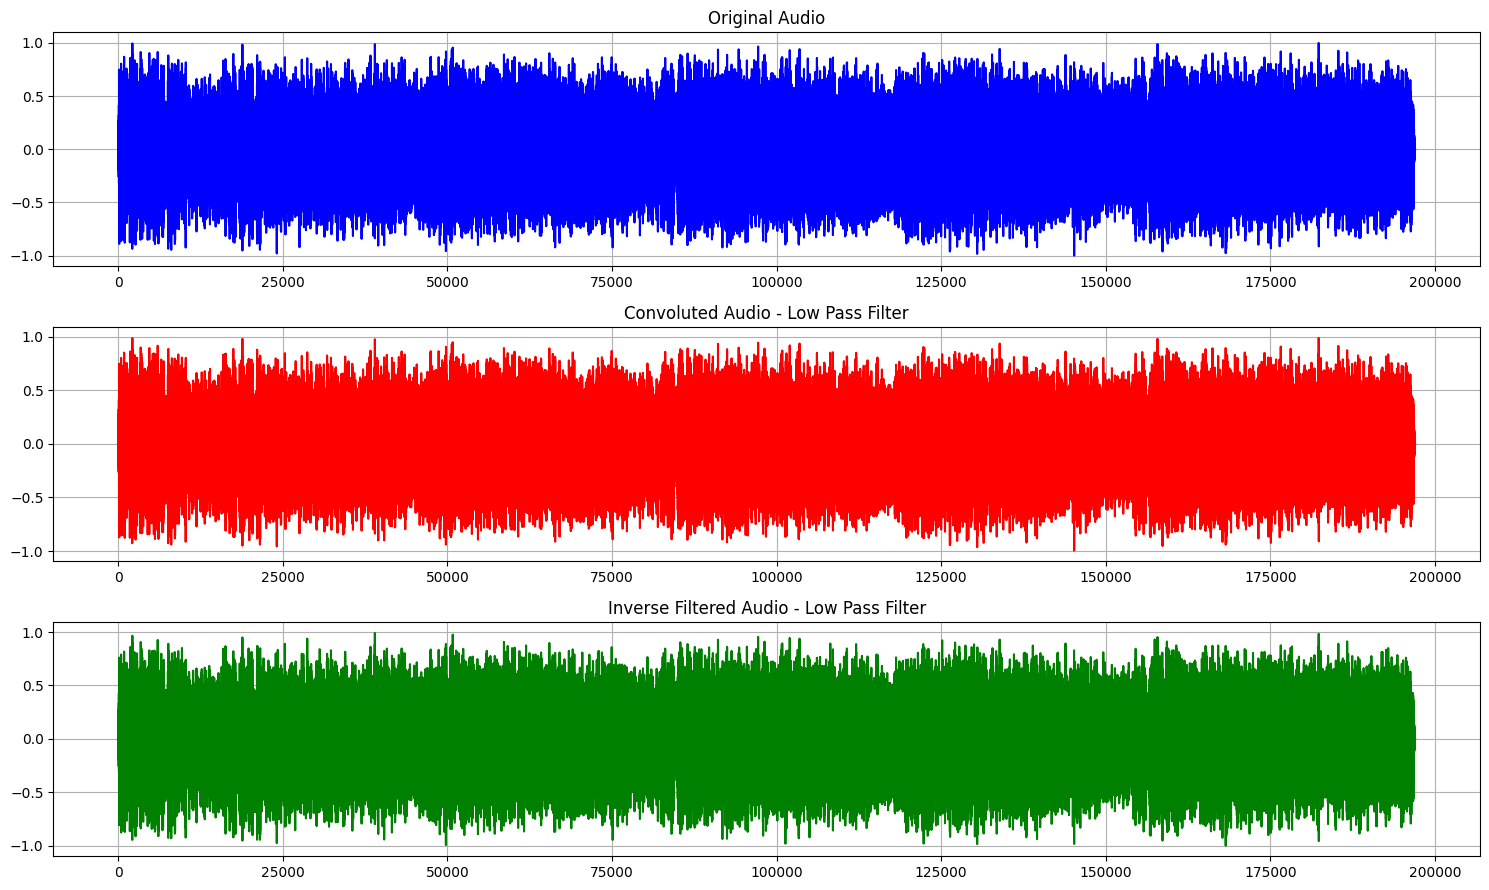

Low Pass Filter Processing Completed


In [6]:
name = "LowPass"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "LowPass_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "LowPass_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Low Pass Filter")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Low Pass Filter")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "LowPass.png"
    )
)

plt.show()

print("Low Pass Filter Processing Completed")

C:\Users\devah\AppData\Local\Temp\ipykernel_15080\3533428708.py:15: RuntimeWarning: divide by zero encountered in divide
  1 / H,
C:\Users\devah\AppData\Local\Temp\ipykernel_15080\3533428708.py:15: RuntimeWarning: invalid value encountered in divide
  1 / H,


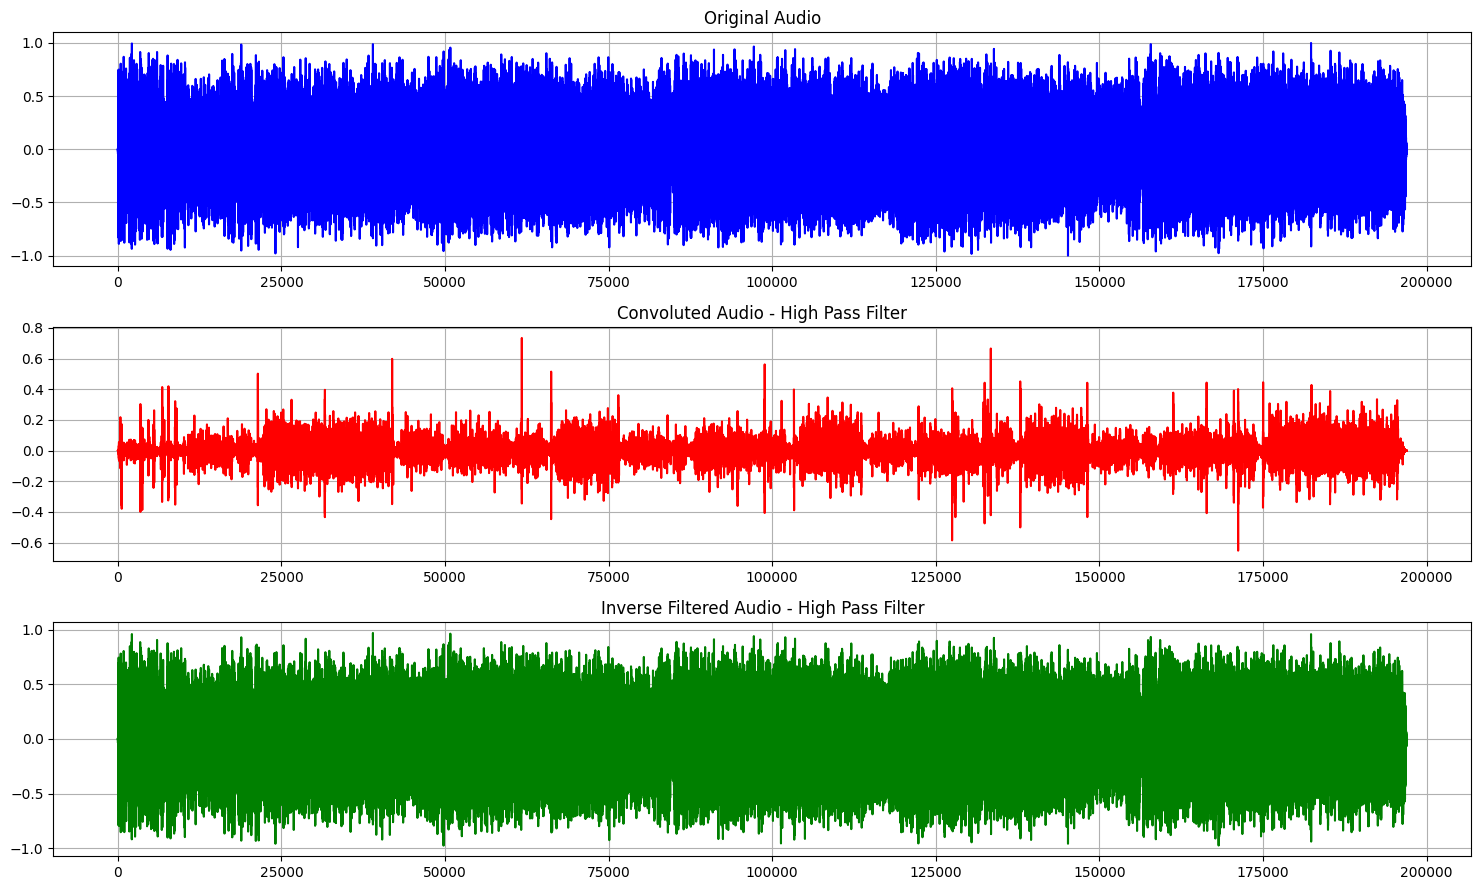

High Pass Filter Processing Completed


In [7]:
name = "HighPass"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "HighPass_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "HighPass_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - High Pass Filter")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - High Pass Filter")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "HighPass.png"
    )
)

plt.show()

print("High Pass Filter Processing Completed")

C:\Users\devah\AppData\Local\Temp\ipykernel_15080\2110426607.py:15: RuntimeWarning: divide by zero encountered in divide
  1 / H,
C:\Users\devah\AppData\Local\Temp\ipykernel_15080\2110426607.py:15: RuntimeWarning: invalid value encountered in divide
  1 / H,


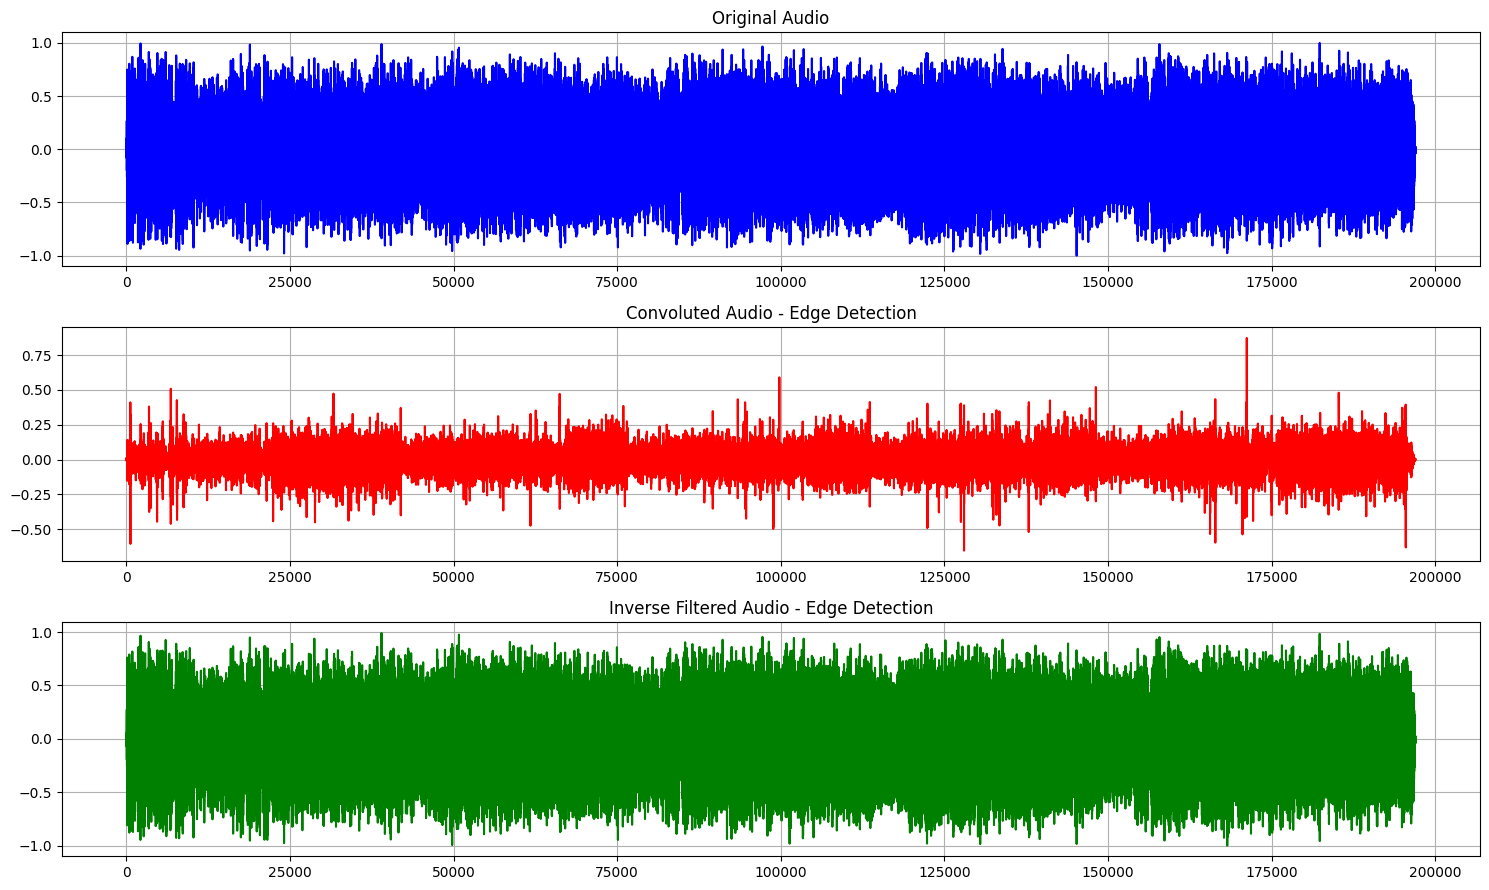

Edge Detection Processing Completed


In [8]:
name = "EdgeDetection"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "EdgeDetection_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "EdgeDetection_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Edge Detection")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Edge Detection")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "EdgeDetection.png"
    )
)

plt.show()

print("Edge Detection Processing Completed")

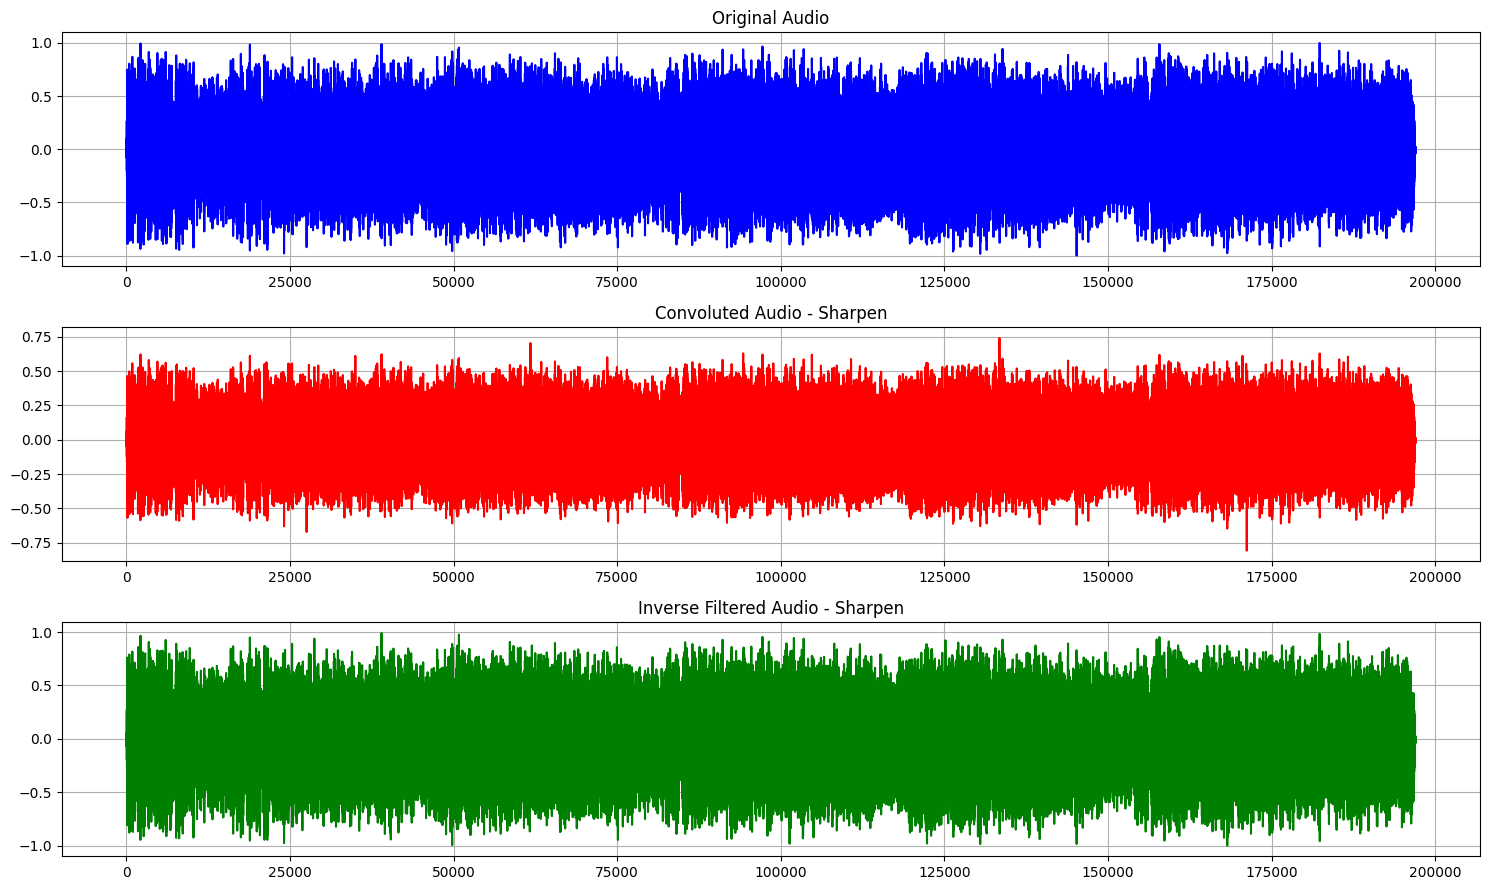

Sharpen Processing Completed


In [9]:
name = "Sharpen"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "Sharpen_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "Sharpen_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Sharpen")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Sharpen")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Sharpen.png"
    )
)

plt.show()

print("Sharpen Processing Completed")

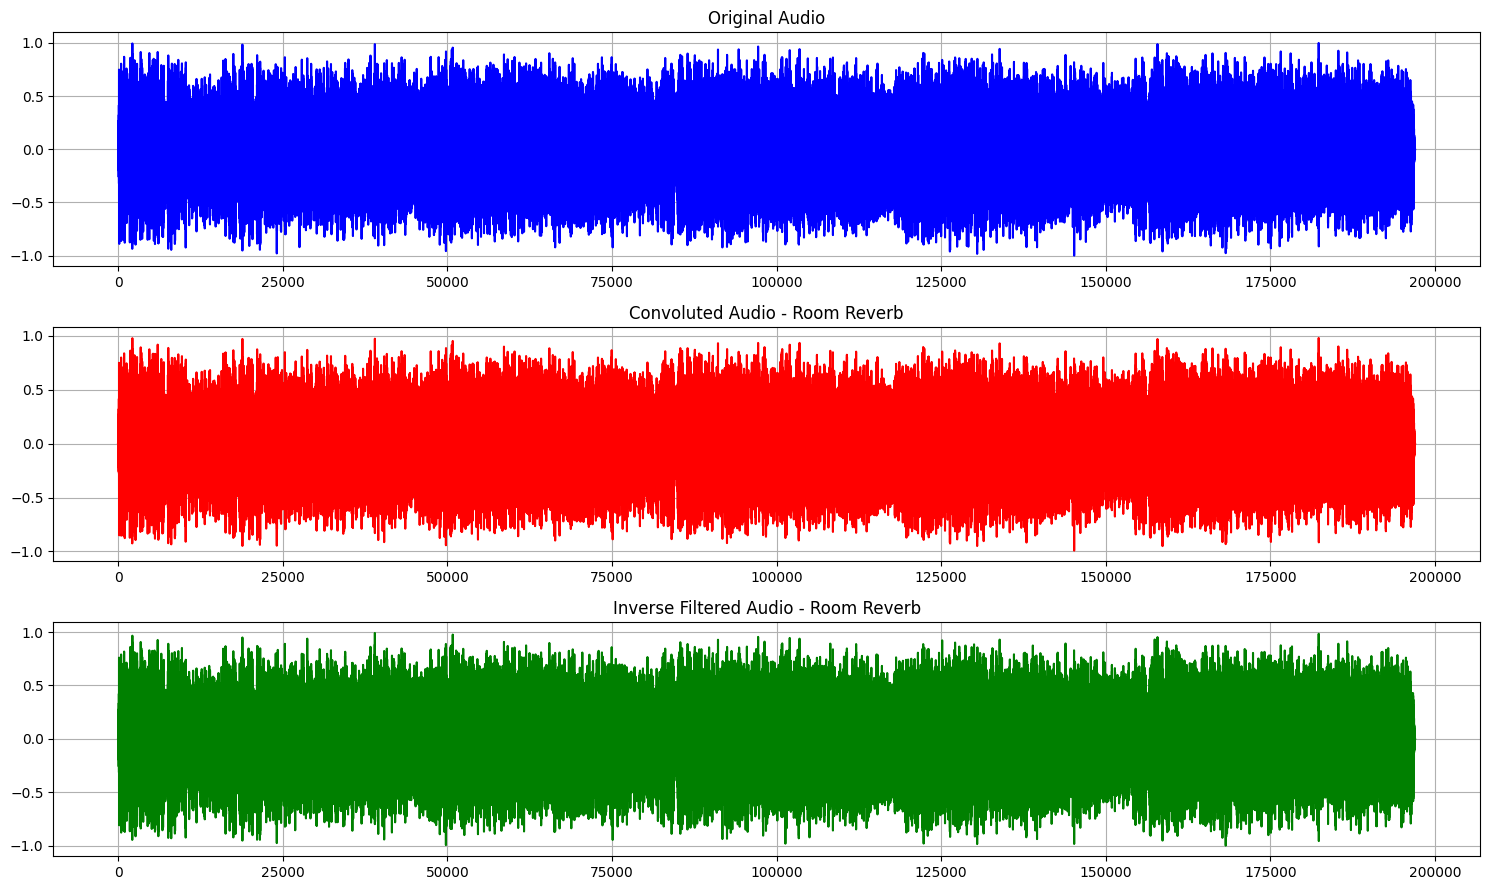

Room Reverb Processing Completed


In [10]:
name = "RoomReverb"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "RoomReverb_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "RoomReverb_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Room Reverb")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Room Reverb")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "RoomReverb.png"
    )
)

plt.show()

print("Room Reverb Processing Completed")

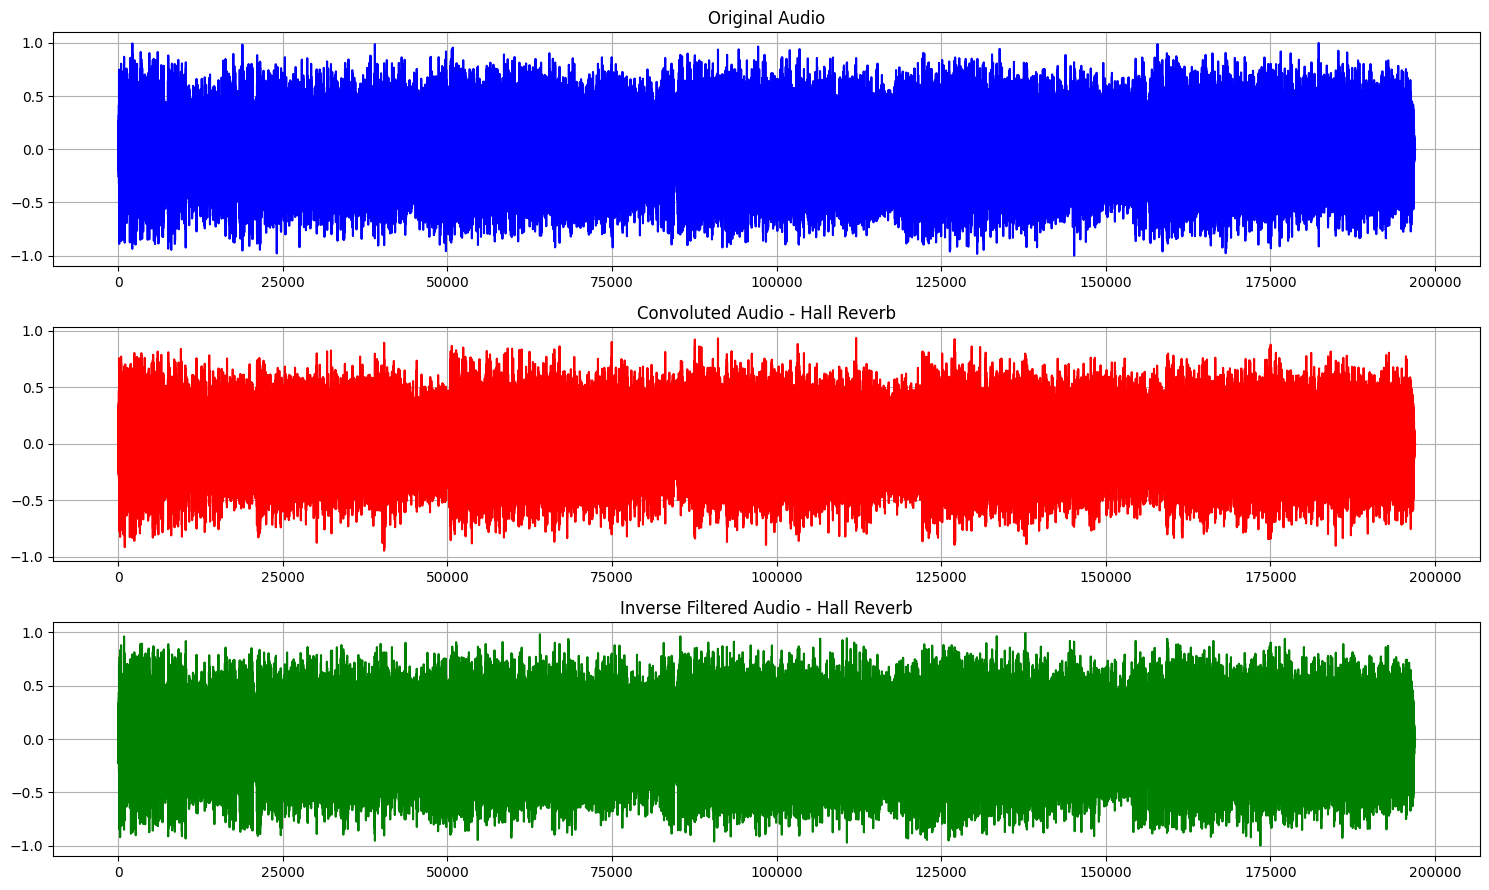

Hall Reverb Processing Completed


In [11]:
name = "HallReverb"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "HallReverb_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "HallReverb_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Hall Reverb")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Hall Reverb")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "HallReverb.png"
    )
)

plt.show()

print("Hall Reverb Processing Completed")

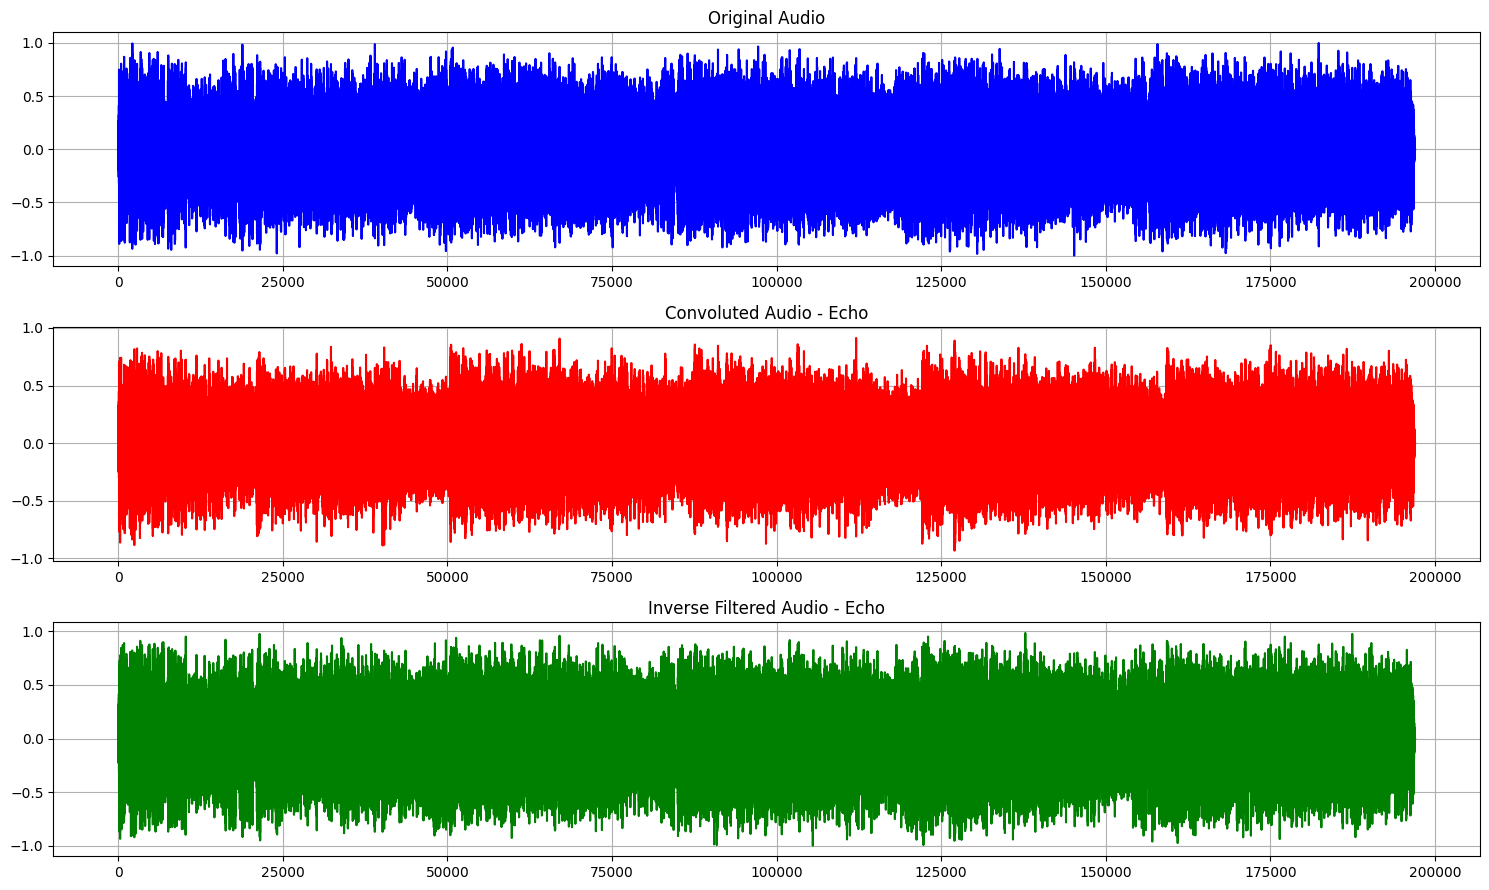

Echo Processing Completed


In [12]:
name = "Echo"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")

convolved = convolved / np.max(np.abs(convolved))

H = fft(h, len(convolved))

epsilon = 1e-6

inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)

restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)

restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "Echo_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "Echo_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)

plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Echo")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Echo")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        graph_folder,
        "Echo.png"
    )
)

plt.show()

print("Echo Processing Completed")

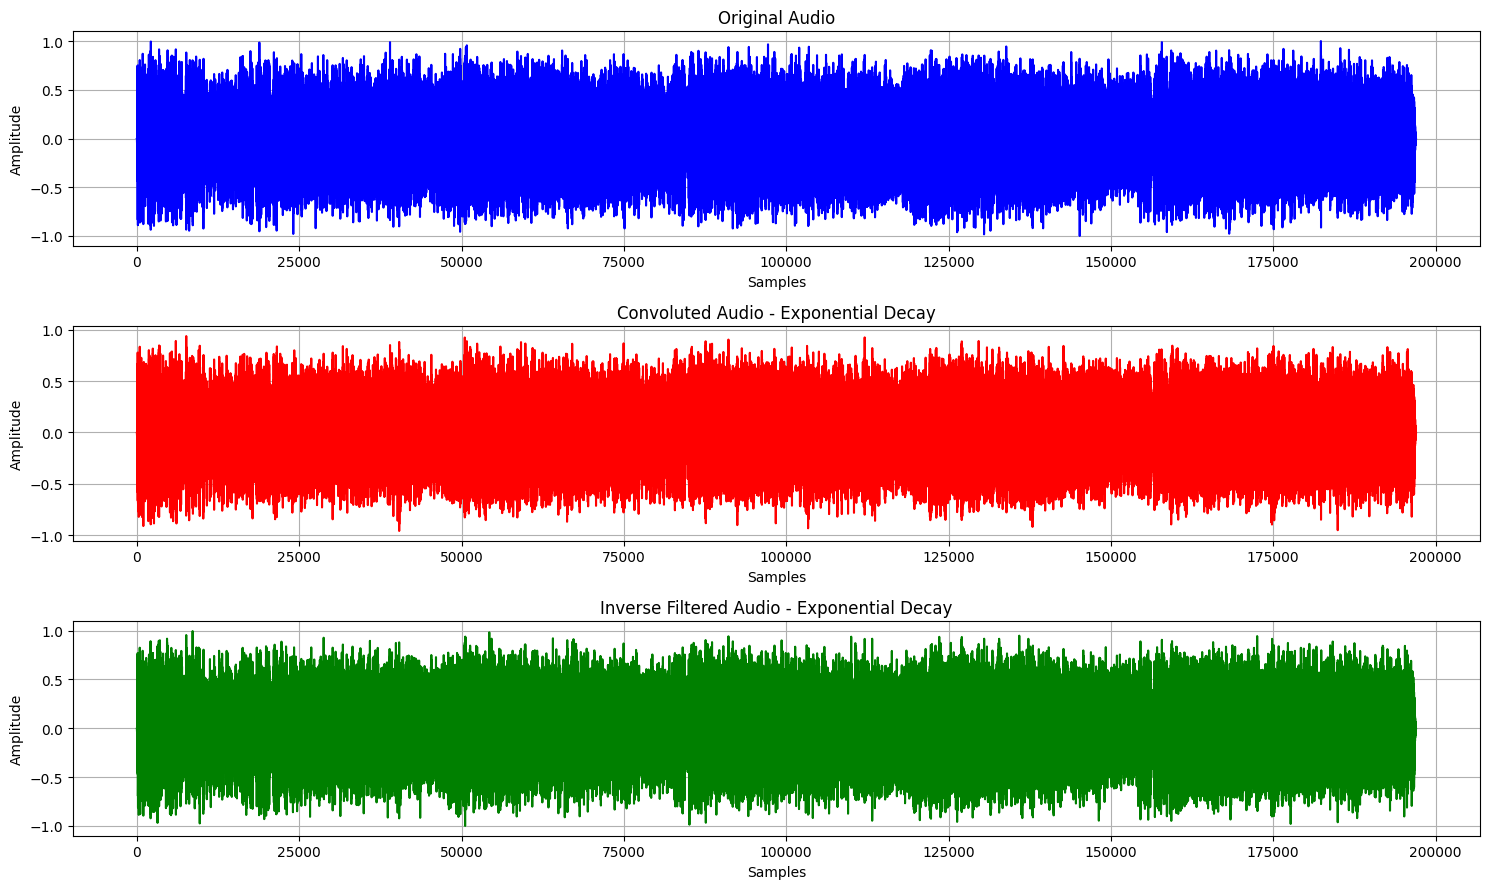

Exponential Decay Processing Completed


In [ ]:
name = "Decay"

h = impulse_responses[name]

convolved = convolve(audio, h, mode="same")
convolved = convolved / np.max(np.abs(convolved))
H = fft(h, len(convolved))
epsilon = 1e-6
inverse_filter = np.where(
    np.abs(H) > epsilon,
    1 / H,
    0
)
restored = np.real(
    ifft(
        fft(convolved) * inverse_filter
    )
)
restored = restored / np.max(np.abs(restored))

wavfile.write(
    os.path.join(
        audio_folder,
        "Decay_Convoluted.wav"
    ),
    fs,
    (convolved * 32767).astype(np.int16)
)

wavfile.write(
    os.path.join(
        audio_folder,
        "Decay_InverseFiltered.wav"
    ),
    fs,
    (restored * 32767).astype(np.int16)
)
plt.figure(figsize=(15,9))

plt.subplot(3,1,1)
plt.plot(audio[::100], color="blue")
plt.title("Original Audio")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(convolved[::100], color="red")
plt.title("Convoluted Audio - Exponential Decay")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(restored[::100], color="green")
plt.title("Inverse Filtered Audio - Exponential Decay")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.savefig(
    os.path.join(
        graph_folder,
        "Decay.png"
    ))
plt.show()
print("Exponential Decay Processing Completed")

In [16]:
print("AUDIO CONVOLUTION AND INVERSE FILTERING COMPLETED")

print("\nGenerated Audio Files\n")

for name in impulse_responses.keys():

    print(f"{name}_Convoluted.wav")
    print(f"{name}_InverseFiltered.wav")

print("\nGenerated Graphs\n")

print("Identity.png")
print("NoiseReduction.png")
print("LowPass.png")
print("HighPass.png")
print("EdgeDetection.png")
print("Sharpen.png")
print("RoomReverb.png")
print("HallReverb.png")
print("Echo.png")
print("Decay.png")

print("\nTotal Convoluted Audio Files      : 10")
print("Total Inverse Filtered Audio Files: 10")
print("Total Graphs                      : 10")

print("\nAudio Folder")

print(os.path.abspath(audio_folder))

print("\nGraph Folder")

print(os.path.abspath(graph_folder))

print("\nExperiment Completed Successfully")

AUDIO CONVOLUTION AND INVERSE FILTERING COMPLETED

Generated Audio Files

Identity_Convoluted.wav
Identity_InverseFiltered.wav
NoiseReduction_Convoluted.wav
NoiseReduction_InverseFiltered.wav
LowPass_Convoluted.wav
LowPass_InverseFiltered.wav
HighPass_Convoluted.wav
HighPass_InverseFiltered.wav
EdgeDetection_Convoluted.wav
EdgeDetection_InverseFiltered.wav
Sharpen_Convoluted.wav
Sharpen_InverseFiltered.wav
RoomReverb_Convoluted.wav
RoomReverb_InverseFiltered.wav
HallReverb_Convoluted.wav
HallReverb_InverseFiltered.wav
Echo_Convoluted.wav
Echo_InverseFiltered.wav
Decay_Convoluted.wav
Decay_InverseFiltered.wav

Generated Graphs

Identity.png
NoiseReduction.png
LowPass.png
HighPass.png
EdgeDetection.png
Sharpen.png
RoomReverb.png
HallReverb.png
Echo.png
Decay.png

Total Convoluted Audio Files      : 10
Total Inverse Filtered Audio Files: 10
Total Graphs                      : 10

Audio Folder
c:\Users\devah\Documents\ICT MU\Sem 5\DSIP\Lab\Processed_Audio

Graph Folder
c:\Users\devah\Docum